# 01 — Regresión Logística por Cluster
**Rol:** Línea base interpretable — cuantifica el efecto directo de cada variable
dentro de cada perfil y permite comparar si los efectos cambian entre clusters y regímenes.

---
**Hipótesis:** Si el mismo predictor tiene coeficientes de signo y magnitud similares
en todos los clusters, constituye un factor de riesgo **universal**. Si varía sustancialmente,
el factor es **específico del perfil**.

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, recall_score, f1_score, precision_score,
                              classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve)
from sklearn.impute   import SimpleImputer
from sklearn.preprocessing import StandardScaler
import time

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path('../../data')
IMG_DIR  = Path('../../data/images/clusters'); IMG_DIR.mkdir(parents=True, exist_ok=True)
CLUSTERED_CSV = DATA_DIR / 'dataset_clustered.csv'

assert CLUSTERED_CSV.exists(), (
    "No se encontró dataset_clustered.csv — ejecutar 00_cluster_profiles.ipynb primero"
)

df = pd.read_csv(CLUSTERED_CSV, low_memory=False)
print(f"✓ dataset_clustered.csv: {df.shape}")

# ── Constantes ────────────────────────────────────────────────────────────────
SEED         = 42
TARGET       = 'retention'
PRETEC21     = ['AD14','AD15','AD16','AD17','AD18']
TEC21        = ['AD19','AD20']
N_CLUSTERS   = df['cluster'].nunique()
MIN_AUC      = 0.60
SKF          = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Features del modelo (excluir fuga y metadatos) ────────────────────────────
EXCLUDE = {TARGET, 'cluster', 'generation', 'regime', 'educational.model'}
FEATURE_COLS_BASE = [c for c in [
    'PNA','admission_test_norm','english.evaluation','admission.rubric','general.math.eval',
    'online.test','FTE','apoyo_financiero',
    'has_extracurriculars','has_physical','has_cultural','has_social',
    'first_gen_enc','educ_padres_max','parents_exatec_enc','socioec_enc','social_lag_enc',
    'age','is_male','estuvo_prepa_tec',
    'foreign_Yes: Foreigner','foreign_Yes: National',
    'zone_enc','zone_Rural','zone_Semiurban','zone_Urban',
    'school_enc','region_enc',
    'first_gen_present','parents_edu_present','took_admission_test',
    'has_socioeconomic_data','has_social_lag_data','has_zone_data',
] if c in df.columns and c not in EXCLUDE]

print(f"Features disponibles: {len(FEATURE_COLS_BASE)}")

# ── Paleta de clusters ────────────────────────────────────────────────────────
CLUSTER_COLORS = ['#2563eb','#dc2626','#16a34a','#f59e0b','#7c3aed','#0891b2']

# ── Helper: preparar datos de un cluster ──────────────────────────────────────
def get_cluster_data(cluster_id, regime=None):
    mask = df['cluster'] == cluster_id
    if regime == 'PreTec21':
        mask &= df['generation'].isin(PRETEC21)
    elif regime == 'Tec21':
        mask &= df['generation'].isin(TEC21)
    sub = df[mask].copy()
    feat_cols = [c for c in FEATURE_COLS_BASE if sub[c].std() > 0]
    imp = SimpleImputer(strategy='median')
    X   = imp.fit_transform(sub[feat_cols].values.astype(float))
    y   = sub[TARGET].values.astype(int)
    return X, y, feat_cols, sub

# ── Helper: evaluar modelo ────────────────────────────────────────────────────
def eval_model(model, X, y, model_name, feat_cols, seed=SEED):
    if len(np.unique(y)) < 2 or (y==0).sum() < 5:
        print(f"    ⚠ Insuficientes desertores — omitido")
        return None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)
    model.fit(X_tr, y_tr)
    has_proba = hasattr(model, 'predict_proba')
    y_proba   = model.predict_proba(X_te)[:,1] if has_proba else None
    y_pred    = model.predict(X_te)
    auc  = roc_auc_score(y_te, y_proba) if (has_proba and len(np.unique(y_te))>1) else 0.5
    rec  = recall_score(y_te, y_pred, zero_division=0)
    prec = precision_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    return dict(model=model_name, auc=auc, recall=rec, precision=prec, f1=f1,
                y_proba=y_proba, y_pred=y_pred, y_te=y_te, feat_cols=feat_cols,
                n_train=len(y_tr), n_test=len(y_te),
                dropout_rate=(y==0).mean(), trained_model=model)

print("\n✓ Setup completo — listo para entrenar modelos por cluster")

✓ dataset_clustered.csv: (77517, 39)
Features disponibles: 34

✓ Setup completo — listo para entrenar modelos por cluster


## 1. Entrenamiento de Regresión Logística por Cluster × Régimen

In [2]:
from sklearn.linear_model import LogisticRegression
try:
    import shap; SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠ SHAP no disponible")

results_lr = {}   # {(cluster, regime): eval_dict}
coef_store = {}   # {(cluster, regime): pd.Series de coefs}

for cluster_id in range(N_CLUSTERS):
    for regime_name, gens in [('PreTec21', ['AD14','AD15','AD16','AD17','AD18']),
                               ('Tec21',   ['AD19','AD20'])]:
        key = (cluster_id, regime_name)
        X, y, feat_cols, sub = get_cluster_data(cluster_id, regime_name)
        n_dropout = (y==0).sum()
        print(f"\nCluster {cluster_id} [{regime_name}]  n={len(y):,}  desertores={n_dropout}")

        if n_dropout < 10 or len(y) < 50:
            print("  ⚠ Muestra insuficiente — omitido")
            continue

        # Escalar antes de LR
        sc  = StandardScaler()
        X_s = sc.fit_transform(X)

        lr  = LogisticRegression(class_weight='balanced', max_iter=2000,
                                  random_state=SEED, solver='lbfgs')
        res = eval_model(lr, X_s, y, 'LogisticRegression', feat_cols)
        if res is None: continue

        results_lr[key] = res
        coef_store[key] = pd.Series(lr.coef_[0], index=feat_cols)
        print(f"  AUC={res['auc']:.3f}  Recall={res['recall']:.3f}  F1={res['f1']:.3f}  "
              f"{'✓' if res['auc']>=MIN_AUC else '⚠'}")


Cluster 0 [PreTec21]  n=20,109  desertores=1143


  AUC=0.633  Recall=0.610  F1=0.747  ✓

Cluster 0 [Tec21]  n=129  desertores=40
  AUC=0.632  Recall=0.722  F1=0.743  ✓

Cluster 1 [PreTec21]  n=9,617  desertores=679
  AUC=0.671  Recall=0.628  F1=0.757  ✓

Cluster 1 [Tec21]  n=19,488  desertores=1421


  AUC=0.655  Recall=0.574  F1=0.717  ✓

Cluster 2 [PreTec21]  n=2,643  desertores=289
  AUC=0.717  Recall=0.682  F1=0.792  ✓

Cluster 2 [Tec21]  n=3,129  desertores=405
  AUC=0.693  Recall=0.631  F1=0.749  ✓

Cluster 3 [PreTec21]  n=20,641  desertores=2574
  AUC=0.665  Recall=0.665  F1=0.771  ✓

Cluster 3 [Tec21]  n=1,761  desertores=262
  AUC=0.607  Recall=0.713  F1=0.788  ✓


## 2. Tabla de métricas comparativa

═══ Regresión Logística — Métricas por Cluster y Régimen ═══
 Cluster  Régimen  n_train   AUC  Recall    F1  Dropout% OK
       0 PreTec21    16087 0.633   0.610 0.747       5.7  ✓
       0    Tec21      103 0.632   0.722 0.743      31.0  ✓
       1 PreTec21     7693 0.671   0.628 0.757       7.1  ✓
       1    Tec21    15590 0.655   0.574 0.717       7.3  ✓
       2 PreTec21     2114 0.717   0.682 0.792      10.9  ✓
       2    Tec21     2503 0.693   0.631 0.749      12.9  ✓
       3 PreTec21    16512 0.665   0.665 0.771      12.5  ✓
       3    Tec21     1408 0.607   0.713 0.788      14.9  ✓


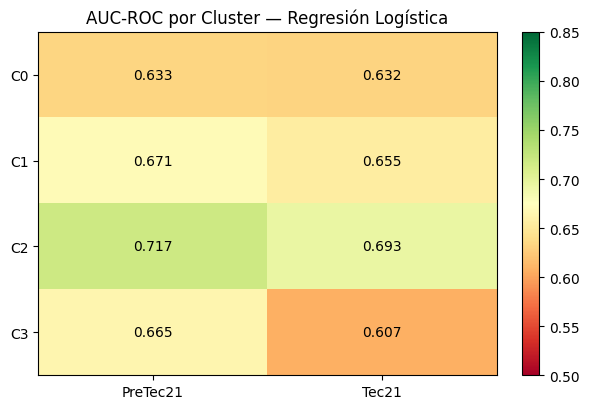

In [3]:
rows = []
for (cl, reg), res in results_lr.items():
    rows.append({'Cluster':cl, 'Régimen':reg, 'n_train':res['n_train'],
                 'AUC':round(res['auc'],3), 'Recall':round(res['recall'],3),
                 'F1':round(res['f1'],3), 'Dropout%':round(res['dropout_rate']*100,1),
                 'OK':('✓' if res['auc']>=MIN_AUC else '⚠')})
tbl = pd.DataFrame(rows).sort_values(['Cluster','Régimen'])
print("═══ Regresión Logística — Métricas por Cluster y Régimen ═══")
print(tbl.to_string(index=False))

# Heatmap de AUC
auc_mat  = pd.DataFrame(index=[f'C{k}' for k in range(N_CLUSTERS)],
                         columns=['PreTec21','Tec21'], dtype=float)
for (cl, reg), res in results_lr.items():
    auc_mat.loc[f'C{cl}', reg] = res['auc']

fig, ax = plt.subplots(figsize=(6, N_CLUSTERS*0.8+1))
im = ax.imshow(auc_mat.values.astype(float), cmap='RdYlGn', vmin=0.5, vmax=0.85, aspect='auto')
ax.set_xticks([0,1]); ax.set_xticklabels(['PreTec21','Tec21'])
ax.set_yticks(range(N_CLUSTERS)); ax.set_yticklabels(auc_mat.index)
ax.set_title('AUC-ROC por Cluster — Regresión Logística')
plt.colorbar(im, ax=ax, fraction=0.04)
for i in range(N_CLUSTERS):
    for j, col in enumerate(['PreTec21','Tec21']):
        v = auc_mat.loc[f'C{i}', col]
        if pd.notna(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=10,
                    color='white' if float(v) < 0.60 else 'black')
plt.tight_layout()
plt.savefig(IMG_DIR / 'lr_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Comparación de coeficientes entre clusters (invarianza)

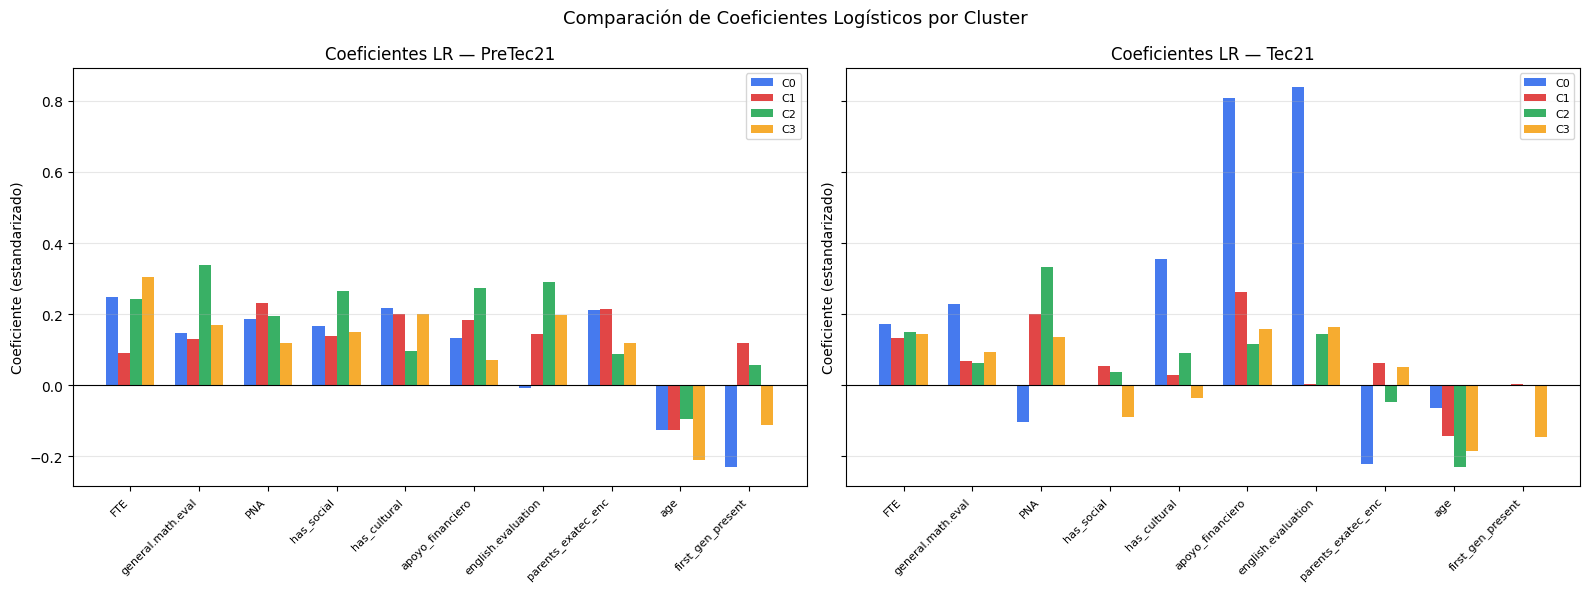

In [4]:
# Top 10 variables por magnitud media de coeficiente (en PreTec21)
pre_coefs = {k: v for (k, r), v in coef_store.items() if r == 'PreTec21'}
if pre_coefs:
    all_feats  = list(next(iter(pre_coefs.values())).index)
    mean_abs   = pd.Series(
        {f: np.mean([abs(pre_coefs[k].get(f,0)) for k in pre_coefs]) for f in all_feats}
    ).sort_values(ascending=False)
    top10 = mean_abs.head(10).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    x = np.arange(len(top10)); w = 0.7 / N_CLUSTERS

    for ax_i, (regime_name, ax) in enumerate([('PreTec21', axes[0]), ('Tec21', axes[1])]):
        for k in range(N_CLUSTERS):
            if (k, regime_name) not in coef_store: continue
            vals = [coef_store[(k, regime_name)].get(f, 0) for f in top10]
            offset = (k - (N_CLUSTERS-1)/2) * w
            ax.bar(x + offset, vals, w, label=f'C{k}',
                   color=CLUSTER_COLORS[k], alpha=0.85)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_xticks(x); ax.set_xticklabels(top10, rotation=45, ha='right', fontsize=8)
        ax.set_title(f'Coeficientes LR — {regime_name}')
        ax.set_ylabel('Coeficiente (estandarizado)')
        ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Comparación de Coeficientes Logísticos por Cluster', fontsize=13)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'lr_coefs_by_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. SHAP — Logistic Regression por cluster

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

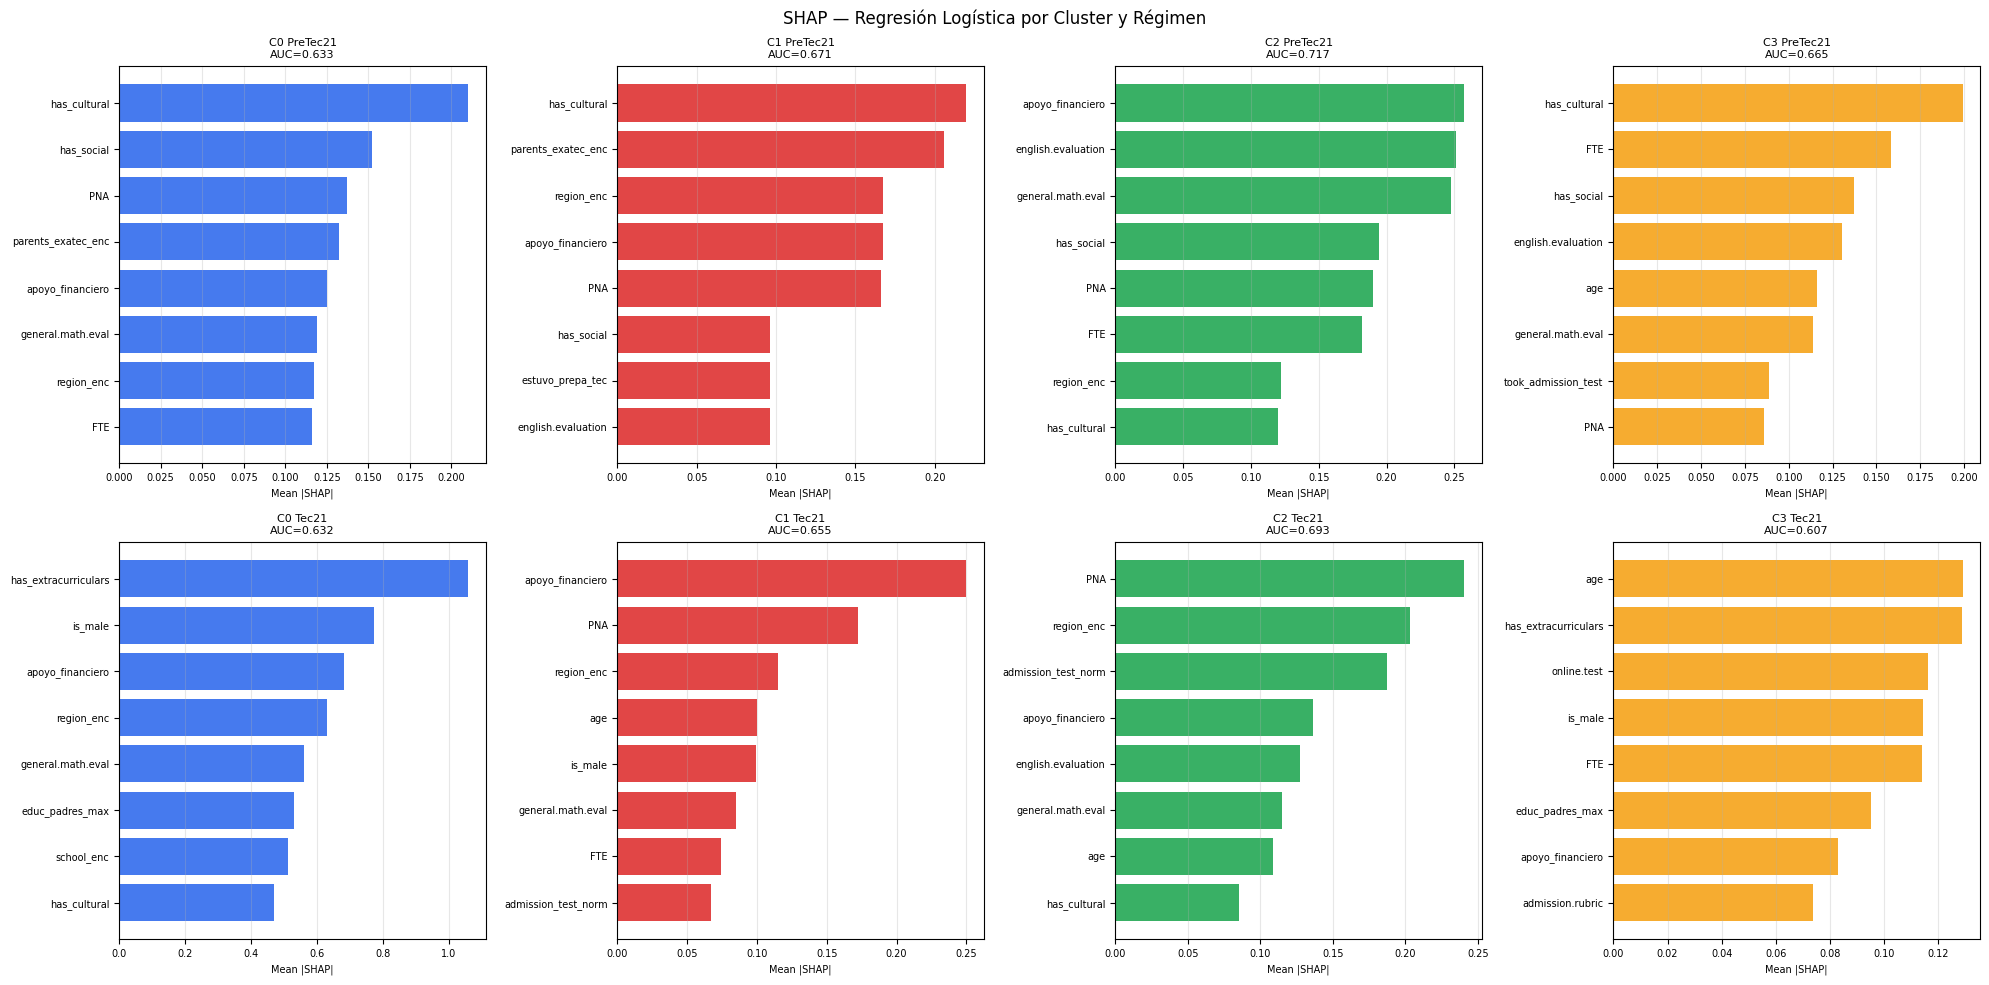

In [5]:
if SHAP_AVAILABLE and results_lr:
    fig, axes = plt.subplots(2, N_CLUSTERS, figsize=(5*N_CLUSTERS, 10))
    if N_CLUSTERS == 1: axes = axes.reshape(2,1)

    for row_i, regime_name in enumerate(['PreTec21', 'Tec21']):
        for col_i, k in enumerate(range(N_CLUSTERS)):
            ax = axes[row_i, col_i]
            key = (k, regime_name)
            if key not in results_lr:
                ax.set_visible(False); continue
            res = results_lr[key]
            # SHAP para LR (LinearExplainer)
            X_cl, y_cl, feat_cols, _ = get_cluster_data(k, regime_name)
            sc_tmp = StandardScaler()
            X_sc   = sc_tmp.fit_transform(X_cl)
            model  = res['trained_model']
            exp    = shap.LinearExplainer(model, X_sc, feature_perturbation='correlation_dependent')
            sv     = exp.shap_values(X_sc[:200])  # submuestra para velocidad
            mean_abs = np.abs(sv).mean(axis=0)
            top5_idx = np.argsort(mean_abs)[::-1][:8]
            ax.barh([feat_cols[i] for i in top5_idx],
                    mean_abs[top5_idx],
                    color=CLUSTER_COLORS[k], alpha=0.85)
            ax.invert_yaxis()
            ax.set_title(f'C{k} {regime_name}\nAUC={res["auc"]:.3f}', fontsize=8)
            ax.set_xlabel('Mean |SHAP|', fontsize=7)
            ax.tick_params(labelsize=7)
            ax.grid(axis='x', alpha=0.3)

    plt.suptitle('SHAP — Regresión Logística por Cluster y Régimen', fontsize=12)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'lr_shap_clusters.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("SHAP no disponible o sin resultados. Instala: pip install shap --break-system-packages")